<a href="https://colab.research.google.com/github/muhammadraffli25/UAS-EDA/blob/main/UAS_EDA%2C_M_Raffli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# INSTALASI & IMPORT

!pip install google-play-scraper pandas matplotlib seaborn textblob wordcloud -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from google_play_scraper import Sort, reviews
from textblob import TextBlob
from wordcloud import WordCloud
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 80)
print('✅')

✅


In [7]:
# ==========================================
# CELL 1: SCRAPING DATA
# ==========================================
import pandas as pd
from google_play_scraper import reviews, Sort

app_id = 'us.zoom.videomeetings'
target_data = 1000

all_reviews = []
continuation_token = None

print(f'🔍 Scraping ulasan dari: {app_id}')

while len(all_reviews) < target_data:
    result, continuation_token = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=200,
        continuation_token=continuation_token
    )
    if not result:
        break
    all_reviews.extend(result)
    print(f'  -> terkumpul: {len(all_reviews)}')
    if continuation_token is None:
        break

df = pd.DataFrame(all_reviews[:target_data])
df = df[['userName', 'content', 'score', 'at']]
df.rename(columns={
    'content': 'teks_ulasan',
    'score'  : 'rating',
    'at'     : 'tanggal_ulasan'
}, inplace=True)

display(df.head())
print(f'Total data final: {len(df)}')

df.to_csv('data_mentah.csv', index=False)

🔍 Scraping ulasan dari: us.zoom.videomeetings
  -> terkumpul: 200
  -> terkumpul: 400
  -> terkumpul: 600
  -> terkumpul: 800
  -> terkumpul: 1000


,userName,teks_ulasan,rating,tanggal_ulasan
0,Veonk Vera,bagus banget,5,2026-06-21 06:26:30
1,BARAYA_CHANNEL,good,5,2026-06-21 06:26:03
2,Adara Ooudy,good,5,2026-06-21 06:03:53
3,Lala belle,Mudah dipakai untuk meeting. Fitur-fiturnya lengkap dan tampilannya jelas.,5,2026-06-21 05:48:06
4,philipi frederick,workplace is better,5,2026-06-21 05:02:15


Total data final: 1000


In [8]:
!pip install PySastrawi

# ==========================================
# CELL 2: TEXT PREPROCESSING
# ==========================================
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Pastikan download corpus yang dibutuhkan
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# --- 1. CLEANING ---
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)       # Hapus URL
    text = re.sub(r'@\w+', ' ', text)                  # Hapus mention
    text = re.sub(r'#\w+', ' ', text)                  # Hapus hashtag
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)         # Hapus emoticon/emoji
    text = re.sub(r'[^a-z ]', ' ', text)               # Hapus simbol & angka (hanya huruf)
    text = " ".join(text.split())
    return text

df['teks_bersih'] = df['teks_ulasan'].apply(clean_text)

# --- 2. TOKENISASI ---
df['tokens'] = df['teks_bersih'].apply(word_tokenize)

# --- 3. STOPWORD REMOVAL ---
# Gabungkan stopwords Bahasa Indonesia dan Bahasa Inggris
stop_words_id = set(stopwords.words('indonesian'))
stop_words_en = set(stopwords.words('english'))
stop_words = stop_words_id.union(stop_words_en)

# Tambahkan slang/kata sambung yang sering bocor ke WordCloud
stop_words |= {'nya','yg','dgn','utk','aja','sih','dong','deh','gak','ga','nih','banget','kalo','nyaa','bg','di'}
# Keluarkan kata negasi agar analisis sentimen negation-aware tetap berfungsi
stop_words -= {'tidak', 'bukan', 'jangan', 'tak', 'not'}

df['tokens_stopword'] = df['tokens'].apply(
    lambda toks: [w for w in toks if w not in stop_words and len(w) > 2]
)

# --- 4. STEMMING (Sastrawi) ---
# Catatan: Proses ini akan memakan waktu lumayan lama untuk 1000 data
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['tokens_stemmed'] = df['tokens_stopword'].apply(lambda toks: [stemmer.stem(w) for w in toks])
df['teks_stemmed']   = df['tokens_stemmed'].apply(lambda toks: ' '.join(toks))

display(df[['teks_ulasan', 'teks_bersih', 'tokens', 'tokens_stopword', 'teks_stemmed']].head())

df.to_csv('data_bersih.csv', index=False)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,teks_ulasan,teks_bersih,tokens,tokens_stopword,teks_stemmed
0,bagus banget,bagus banget,"[bagus, banget]",[bagus],bagus
1,good,good,[good],[good],good
2,good,good,[good],[good],good
3,Mudah dipakai untuk meeting. Fitur-fiturnya lengkap dan tampilannya jelas.,mudah dipakai untuk meeting fitur fiturnya lengkap dan tampilannya jelas,"[mudah, dipakai, untuk, meeting, fitur, fiturnya, lengkap, dan, tampilannya,...","[mudah, dipakai, meeting, fitur, fiturnya, lengkap, tampilannya]",mudah pakai meeting fitur fiturnya lengkap tampil
4,workplace is better,workplace is better,"[workplace, is, better]","[workplace, better]",workplace better


In [9]:
# ==========================================
# CELL 3: ANALISIS SENTIMEN (STRICT POSITIF/NEGATIF)
# ==========================================
# Kamus diperluas (termasuk English & slang)
positif_words = {
    'bagus','hebat','mantap','keren','membantu','mudah','cepat','canggih',
    'sempurna','suka','senang','bisa','lancar','oke','ok','recommended',
    'rekomen','top','jos','gokil','works','berhasil','nyambung','makasih',
    'terima','kasih','puas','worth','gratis','bantu','rapi','jelas','efektif',
    'nyaman','berguna','sip','mantul','good','great','awesome','nice','best',
    'love','perfect','helpful'
}

negatif_words = {
    'jelek','buruk','lambat','gagal','susah','mahal','rusak','kecewa',
    'bohong','hapus','delete','nyebelin','lemot','lag','berbayar','paksa',
    'parah','error','crash','bug','lola','ribet','penipuan','sampah','bapuk',
    'sulit','payah','ampas','bad','worst','poor','terrible','useless','slow','hard'
}

negation_words = {
    'tidak','tak','gak','ga','nggak','ngga','enggak','kaga','blm',
    'belum','bukan','jangan','not','dont','don\'t'
}

def get_sentiment(tokens):
    if not tokens:
        return 0.0
    score = 0.0
    for i, w in enumerate(tokens):
        is_negated = i > 0 and tokens[i-1] in negation_words
        if w in positif_words:
            score += -0.3 if is_negated else 0.3
        elif w in negatif_words:
            score += 0.3 if is_negated else -0.3
    return max(-1.0, min(1.0, score))

def categorize_sentiment(score, rating):
    # Jika sistem berhasil mendeteksi skor dari kata-kata
    if score > 0.0:
        return 'Positif'
    elif score < 0.0:
        return 'Negatif'
    # Jika sistem gagal mendeteksi (skor 0.0), gunakan rating sebagai patokan
    else:
        return 'Positif' if rating >= 4 else 'Negatif'

df['skor_sentimen'] = df['tokens'].apply(get_sentiment)

# Gunakan fungsi apply dengan axis=1 agar bisa membaca kolom skor_sentimen dan rating sekaligus
df['kategori_sentimen'] = df.apply(lambda row: categorize_sentiment(row['skor_sentimen'], row['rating']), axis=1)

print(df['kategori_sentimen'].value_counts())
display(df[['teks_bersih', 'skor_sentimen', 'kategori_sentimen', 'rating']].head(10))

df.to_csv('data_sentimen.csv', index=False)

kategori_sentimen
Positif    702
Negatif    298
Name: count, dtype: int64


,teks_bersih,skor_sentimen,kategori_sentimen,rating
0,bagus banget,0.3,Positif,5
1,good,0.3,Positif,5
2,good,0.3,Positif,5
3,mudah dipakai untuk meeting fitur fiturnya lengkap dan tampilannya jelas,0.6,Positif,5
4,workplace is better,0.0,Positif,5
5,sering dipake di kantor anti lemot,-0.3,Negatif,5
6,lagi liburan tiba tiba disuruh rapat untung saja ada zoom alhasil rapatnya b...,0.3,Positif,5
7,aplikasi buat zoom terbaik,0.0,Positif,5
8,aplikasi terbaik buat meeting online saya sudah menggunakannya beberapa tahu...,0.0,Positif,5
9,menurut saya zoom sangat membantu untuk meeting belajar maupun diskusi secar...,0.6,Positif,5


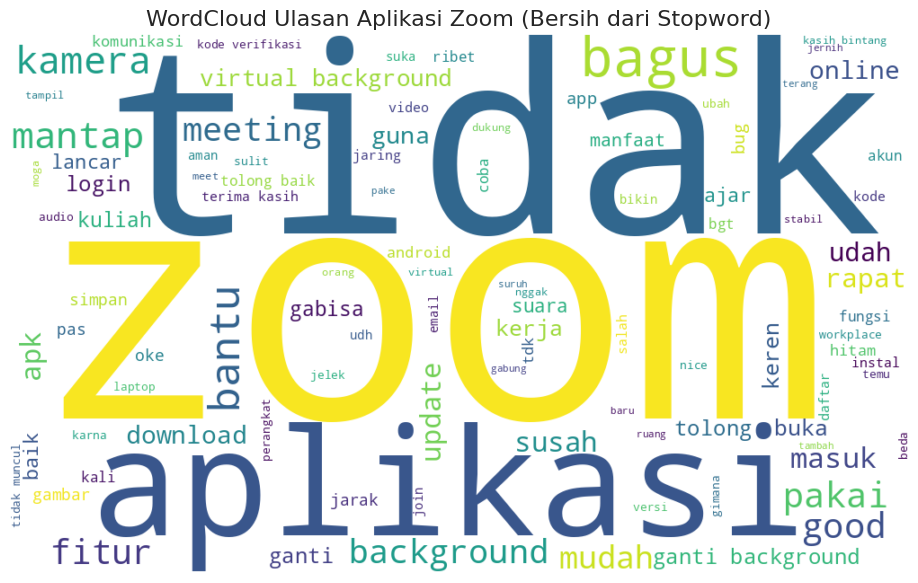

In [10]:
# ==========================================
# CELL 4: WORDCLOUD
# ==========================================
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# PERBAIKAN: Gunakan 'teks_stemmed' agar WordCloud bersih dari stopword,
# BUKAN 'teks_bersih' seperti sebelumnya.
all_text = ' '.join(df['teks_stemmed'].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(all_text)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Ulasan Aplikasi Zoom (Bersih dari Stopword)', fontsize=16)
plt.savefig('wordcloud.png', bbox_inches='tight', dpi=150)
plt.show() # ganti dari teks_bersih

kategori_sentimen
Positif    702
Negatif    298
Name: count, dtype: int64


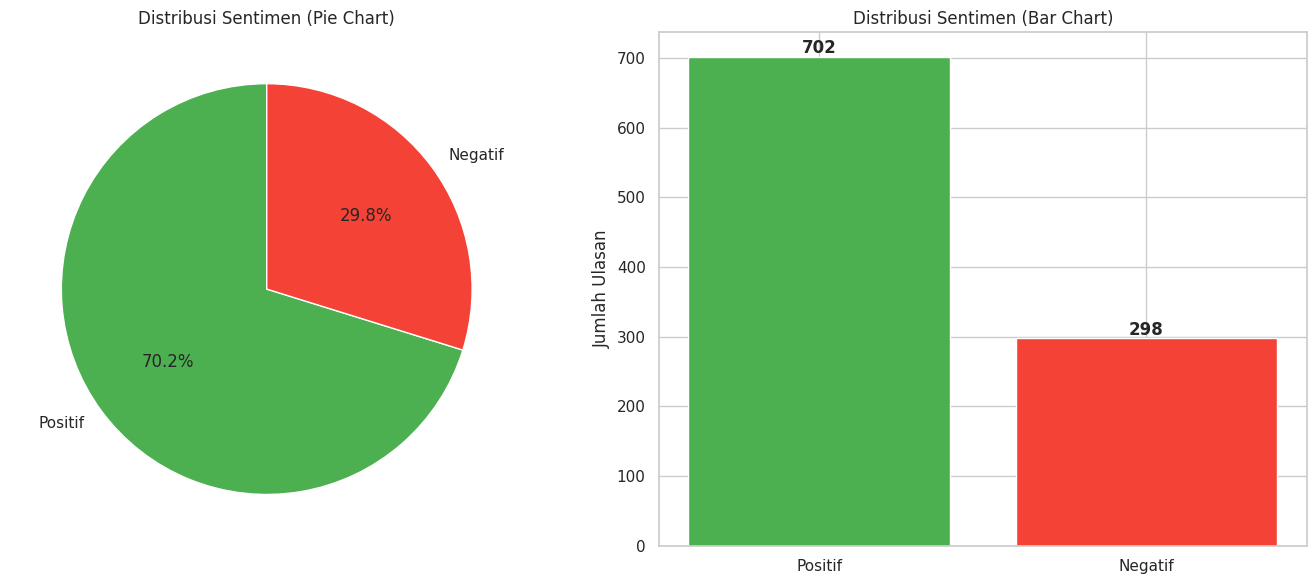

In [11]:
# ==========================================
# CELL 5: VISUALISASI DISTRIBUSI SENTIMEN
# ==========================================
import matplotlib.pyplot as plt

sentiment_counts = df['kategori_sentimen'].value_counts()
print(sentiment_counts)

# Hanya dua warna sesuai instruksi
warna = {'Positif': '#4CAF50', 'Negatif': '#F44336'}
colors = [warna.get(label, '#9E9E9E') for label in sentiment_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0].set_title('Distribusi Sentimen (Pie Chart)')

# Bar chart
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[1].set_title('Distribusi Sentimen (Bar Chart)')
axes[1].set_ylabel('Jumlah Ulasan')
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', bbox_inches='tight', dpi=150)
plt.show()

In [12]:
from google.colab import files
files.download('data_mentah.csv')
files.download('data_bersih.csv')
files.download('data_sentimen.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>